<a href="https://colab.research.google.com/github/rebatoma/italian_pension_investigation/blob/initialization/pension_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pension investigation for year 2024

In [1]:
# All required imports

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Download data and create data frame:

csv_url = 'https://www.inps.it/content/dam/inps-site/opendata/2024/08/dataset_6002.csv'
df_pension = pd.read_csv(csv_url)

In [4]:
pensions_by_region = df_pension.groupby('Regione')['Numero_pensioni'].sum().reset_index()

,Regione,Numero_pensioni
0,Abruzzo,82649.0
1,Basilicata,36802.0
2,Calabria,125225.0
3,Campania,300763.0
4,Emilia Romagna,297616.0


In [50]:
import pandas as pd

# It's important to reload df_popolazione correctly here to ensure accurate column headers.
# The original CSV has a descriptive title in the first row, and actual headers
# (Fascia, Italia, etc.) in the second row (index 1). We also use latin1 encoding.
df_popolazione = pd.read_csv('/content/popolazione_per_regionecsv.csv', encoding='latin1', header=1)

# Clean column names by stripping leading/trailing whitespace
df_popolazione.columns = df_popolazione.columns.str.strip()

# Define age groups for 60+
age_groups_60_plus = [
    '60-64', '65-69', '70-74', '75-79', '80-84', '85-89', '90-94', '95-99', '100+'
]

# Filter DataFrame for these age groups
df_60_plus_filtered = df_popolazione[df_popolazione['Fascia'].isin(age_groups_60_plus)].copy()

# Identify region columns (all columns except 'Fascia')
region_cols = [col for col in df_popolazione.columns if col != 'Fascia']

# Convert relevant columns to numeric, handling potential non-numeric values and thousands separators
for col in region_cols:
    if col in df_60_plus_filtered.columns:
        df_60_plus_filtered[col] = pd.to_numeric(
            df_60_plus_filtered[col].astype(str).str.replace('.', '', regex=False),
            errors='coerce'
        )

# Calculate sums for each region for the '60+' fascia
sums_60_plus = df_60_plus_filtered[region_cols].sum()

# Create a new row (Series) for the '60+' fascia
new_row_data = {'Fascia': '60+'}
new_row_data.update(sums_60_plus.to_dict())

# Convert the dictionary to a DataFrame row
new_row_df = pd.DataFrame([new_row_data])

# Append the new row to df_popolazione
df_popolazione = pd.concat([df_popolazione, new_row_df], ignore_index=True)

# Display the updated DataFrame (last few rows to show the new fascia)
print("DataFrame df_popolazione after adding '60+' fascia:")
display(df_popolazione)

DataFrame df_popolazione after adding '60+' fascia:


,Fascia,Italia,Piemonte,Valle D'Aosta,Lombardia,Trentino Alto Adige,Veneto,Friuli Venezia Giulia,Liguria,Emilia Romagna,...,Marche,Lazio,Abruzzo,Molise,Campania,Puglia,Basilicata,Calabria,Sicilia,Sardegna
0,0-4,1.982.901,132.542,3.713,342.912,44.850,160.470,36.661,43.936,149.148,...,45.652,185.401,40.282,8.340,217.949,130.567,16.263,66.902,182.486,38.890
1,5-9,2.343.317,158.134,4.561,410.710,50.940,189.079,42.747,51.356,175.269,...,55.550,228.200,48.537,10.167,247.325,151.721,19.465,77.418,206.619,50.606
2,10-14,2.693.831,185.089,5.664,470.909,55.252,220.891,50.434,60.383,202.246,...,66.090,267.427,55.886,11.488,275.000,175.898,21.658,83.851,226.332,62.366
3,15-19,2.927.678,199.637,6.194,505.178,57.510,240.394,55.083,67.238,216.124,...,71.522,282.096,59.386,12.766,309.023,194.470,25.128,91.602,250.917,68.155
4,20-24,2.984.030,205.231,6.141,506.512,59.137,244.542,56.780,69.602,216.974,...,72.438,275.213,60.913,14.221,322.278,207.340,27.828,96.068,258.082,69.657
5,25-29,3.036.266,216.023,6.068,528.990,60.928,250.995,57.721,72.683,229.963,...,73.696,280.008,62.071,15.182,315.070,202.670,27.842,96.326,253.937,69.611
6,30-34,3.196.769,224.038,6.107,559.205,62.217,255.216,59.770,75.158,246.002,...,75.467,305.880,66.690,15.682,328.991,209.763,29.018,102.747,270.127,76.553
7,35-39,3.342.904,228.804,6.408,582.203,62.265,263.119,62.126,76.775,252.075,...,79.973,331.143,71.789,16.060,339.246,219.212,30.036,110.361,282.107,85.055
8,40-44,3.616.512,245.373,6.966,625.497,65.492,284.980,68.008,80.278,272.513,...,89.307,369.622,78.865,17.100,359.801,239.028,31.922,115.648,298.426,97.817
9,45-49,4.210.860,292.671,8.510,725.893,72.220,343.806,82.258,97.121,325.881,...,106.880,426.870,90.351,19.712,396.516,283.362,36.521,127.304,333.657,118.003


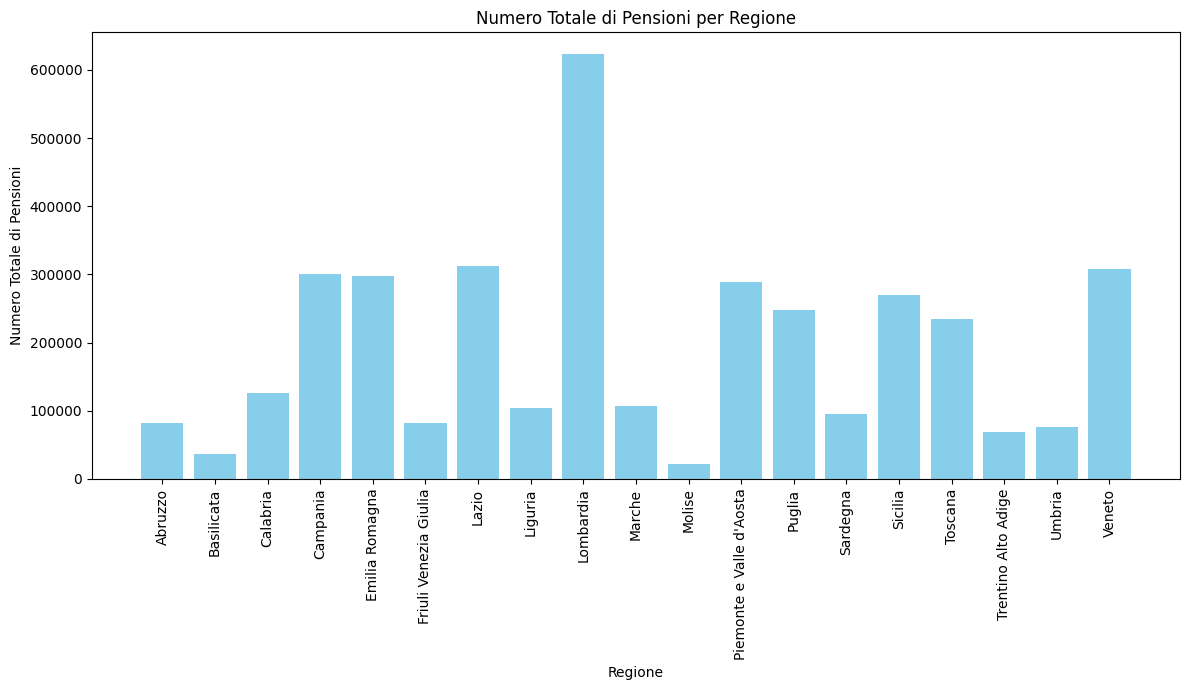

In [5]:
plt.figure(figsize=(12, 7))
plt.bar(pensions_by_region['Regione'], pensions_by_region['Numero_pensioni'], color='skyblue')
plt.xlabel('Regione')
plt.ylabel('Numero Totale di Pensioni')
plt.title('Numero Totale di Pensioni per Regione')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [51]:
# Extract the '60+' row from df_popolazione
df_60_plus_population = df_popolazione[df_popolazione['Fascia'] == '60+'].drop(columns=['Fascia']).transpose().reset_index()
df_60_plus_population.columns = ['Regione', 'Popolazione_60_plus']

# Exclude 'Italia' as it's the national total, not a specific region for comparison
df_60_plus_population = df_60_plus_population[df_60_plus_population['Regione'] != 'Italia']

display(df_60_plus_population.head())

,Regione,Popolazione_60_plus
1,Piemonte,1175670.0
2,Valle D'Aosta,45191.0
3,Lombardia,3125611.0
4,Trentino Alto Adige,328312.0
5,Veneto,1585639.0


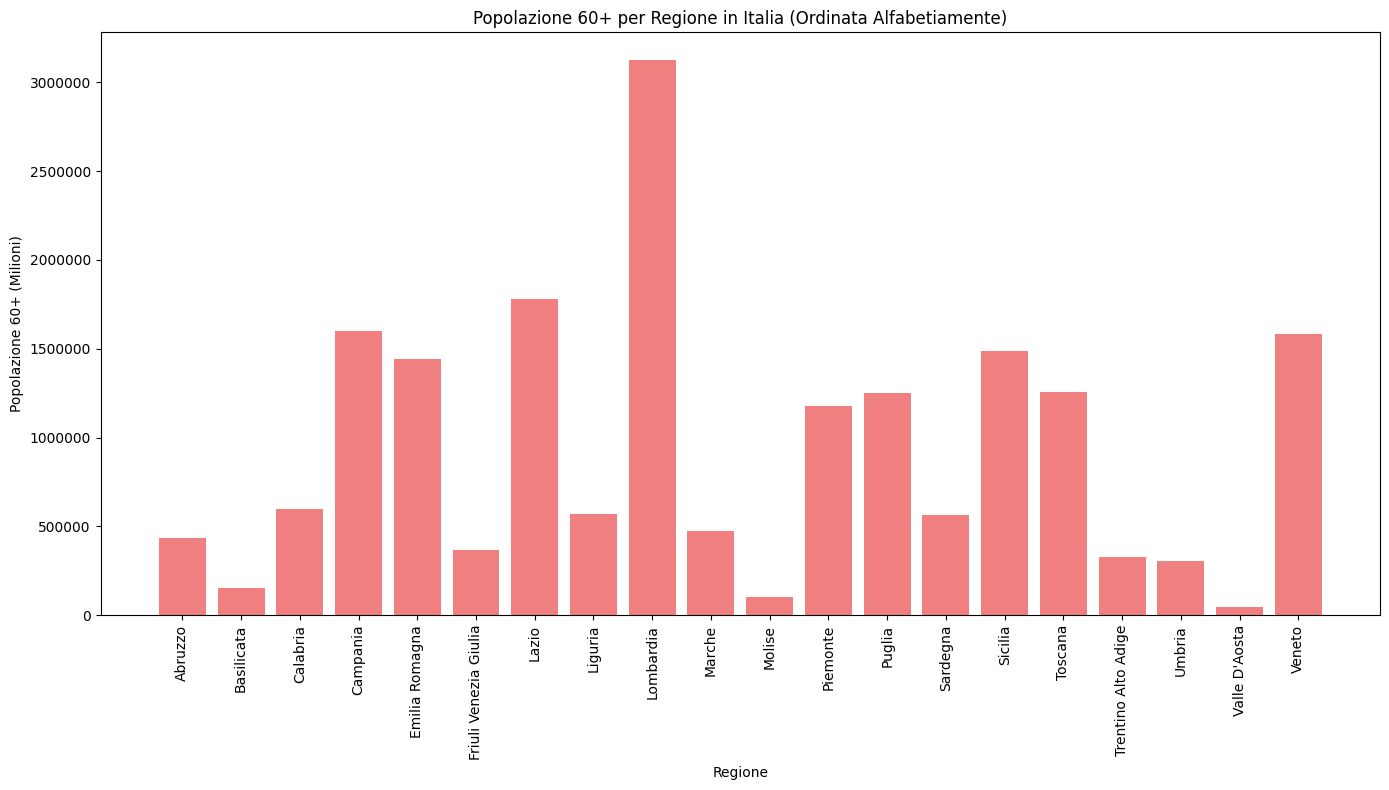

In [54]:
# Sort the DataFrame by 'Regione' alphabetically
df_60_plus_population_sorted = df_60_plus_population.sort_values(by='Regione').copy()

plt.figure(figsize=(14, 8))
plt.bar(df_60_plus_population_sorted['Regione'], df_60_plus_population_sorted['Popolazione_60_plus'], color='lightcoral')
plt.xlabel('Regione')
plt.ylabel('Popolazione 60+ (Milioni)')
plt.title('Popolazione 60+ per Regione in Italia (Ordinata Alfabetiamente)')
plt.xticks(rotation=90)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.tight_layout()
plt.show()

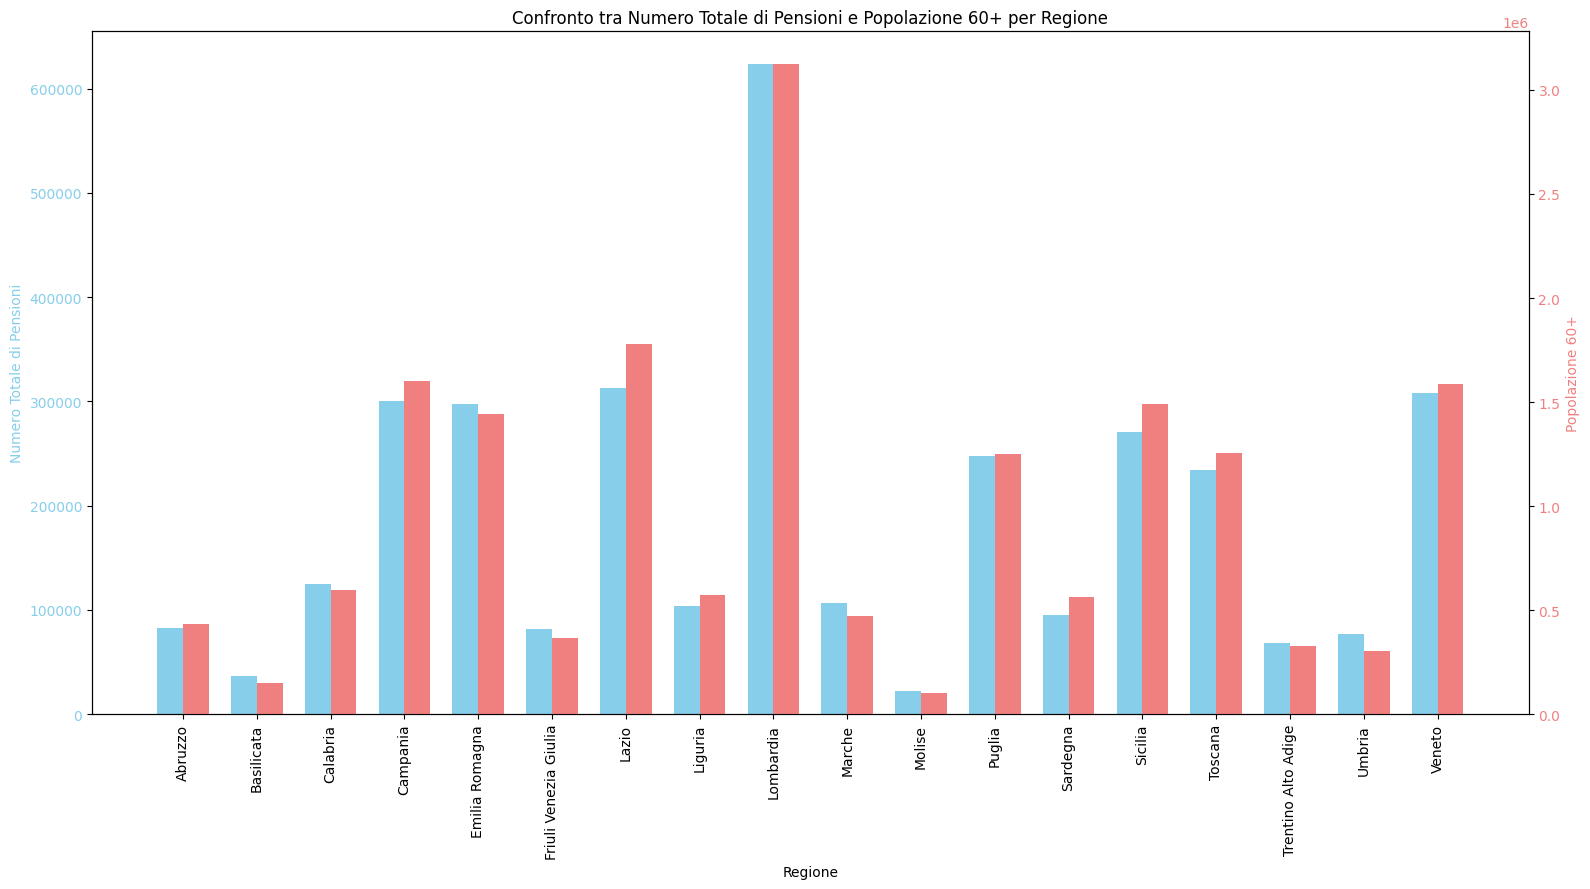

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure both dataframes are sorted by region for consistent merging and plotting
pensions_by_region_sorted = pensions_by_region.sort_values(by='Regione').copy()
df_60_plus_population_sorted_copy = df_60_plus_population_sorted.sort_values(by='Regione').copy()

# Merge the two dataframes on 'Regione'
df_combined = pd.merge(pensions_by_region_sorted, df_60_plus_population_sorted_copy, on='Regione')

# Set up the plot with a dual y-axis
fig, ax1 = plt.subplots(figsize=(16, 9))

# Define bar width and positions
bar_width = 0.35
index = range(len(df_combined['Regione']))

# Plot pensions on the first y-axis (left)
bars1 = ax1.bar([i - bar_width/2 for i in index], df_combined['Numero_pensioni'], bar_width, label='Numero Totale di Pensioni', color='skyblue')
ax1.set_xlabel('Regione')
ax1.set_ylabel('Numero Totale di Pensioni', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Create a second y-axis for population (right)
ax2 = ax1.twinx() # Create a twin Axes sharing the x-axis
bars2 = ax2.bar([i + bar_width/2 for i in index], df_combined['Popolazione_60_plus'], bar_width, label='Popolazione 60+', color='lightcoral')
ax2.set_ylabel('Popolazione 60+', color='lightcoral')
ax2.tick_params(axis='y', labelcolor='lightcoral')

# Set x-axis ticks and labels
ax1.set_xticks(index)
ax1.set_xticklabels(df_combined['Regione'], rotation=90)

plt.title('Confronto tra Numero Totale di Pensioni e Popolazione 60+ per Regione')
fig.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

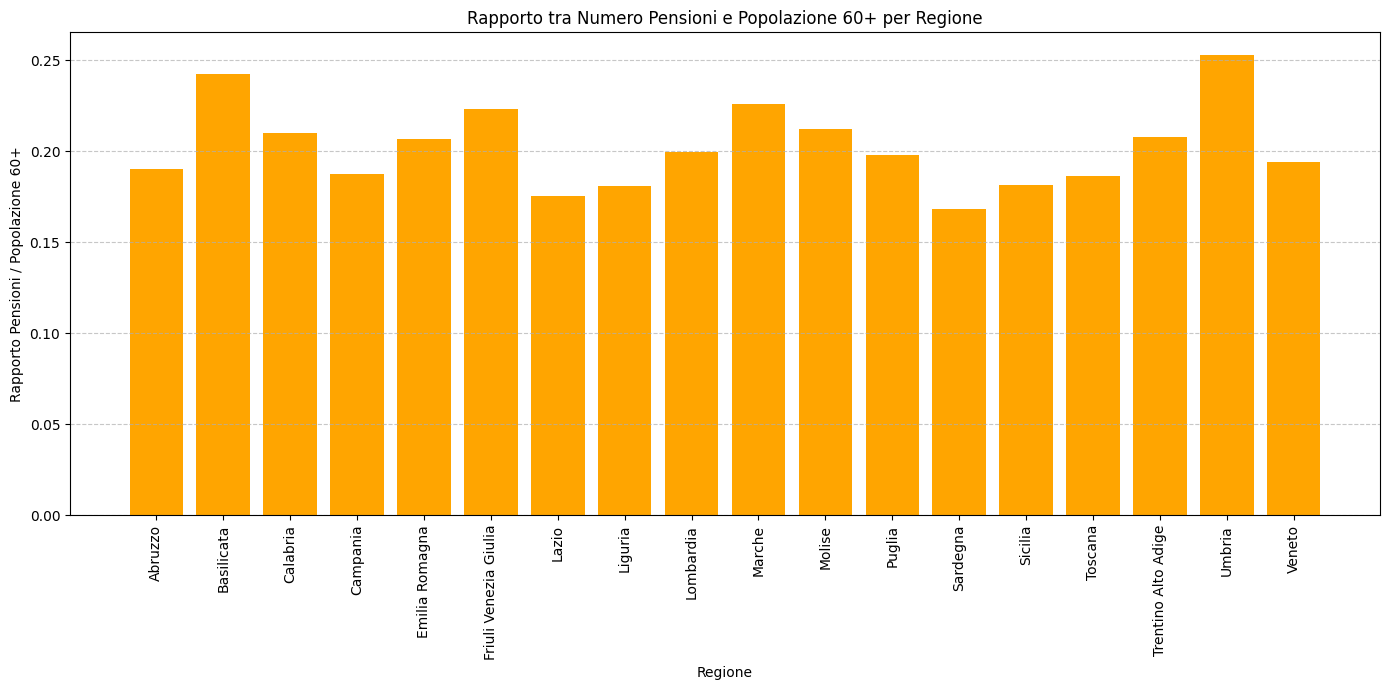

In [57]:
# Calculate the ratio of Numero_pensioni to Popolazione_60_plus
df_combined['Pension_to_Population_Ratio'] = df_combined['Numero_pensioni'] / df_combined['Popolazione_60_plus']

# Create the histogram (bar plot)
plt.figure(figsize=(14, 7))
plt.bar(df_combined['Regione'], df_combined['Pension_to_Population_Ratio'], color='orange')

plt.xlabel('Regione')
plt.ylabel('Rapporto Pensioni / Popolazione 60+')
plt.title('Rapporto tra Numero Pensioni e Popolazione 60+ per Regione')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()